# Simplified HRM (Hierarchical Reasoning Model) for a Toy RTS-like RL Task

This notebook reproduces a simplified version of the HRM architecture and applies it to a synthetic RL task that imitates key characteristics of RTS micro-management: spatial navigation, resource collection, and build/attack phases.

- Target paper: [HRM (Hierarchical Reasoning Model)](https://arxiv.org/pdf/2506.21734)
- Goal: focus on research fidelity over infrastructure. No online gameplay.

Outline:
1. Problem setup: Toy RTS-like gridworld
2. HRM architecture: Manager (high-level intentions) + Worker (low-level skills)
3. PPO training setup for hierarchical policies
4. Training and analysis
5. Evaluation and ablations


In [3]:
#%pip install numpy
#%pip install torch
#%pip install matplotlib

In [1]:
# Imports and basic setup
import os
import math
import random
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

@dataclass
class Config:
    grid_size: int = 10
    num_resources: int = 5
    episode_length: int = 1024
    max_inventory: int = 5
    base_build_cost: int = 3
    enemy_spawn_step: int = 60
    num_enemies: int = 2

    manager_hidden: int = 512
    worker_hidden: int = 512
    intent_dim: int = 128
    manager_intent_horizon: int = 4
    worker_max_iter: int = 6
    worker_act_eps: float = 0.05
    ponder_cost: float = 0.01

    learning_rate: float = 3e-4
    gamma: float = 0.999
    gae_lambda: float = 0.99
    clip_range: float = 0.2
    ppo_epochs: int = 2
    batch_size: int = 4096

cfg = Config()


## Environment: Toy RTS-like Gridworld

- Grid with player base at center, player unit, resources scattered, and occasional enemies.
- Actions (worker): move in 4 directions, gather, build, attack, wait.
- High-level intents (manager): gather → build → scout → attack.
- Rewards: +1 per resource delivered to base; +3 for building outpost; +2 per enemy defeated; small step penalty to encourage efficiency.


In [2]:
# Smoke test the Clash Royale engine
from cr_engine import CREngine, RandomPolicy

e = CREngine()
p0 = RandomPolicy()
p1 = RandomPolicy()
R0, R1, steps = e.self_play_episode(p0, p1, render=False)
R0, R1, steps


(-2.38, 2.38, 39)

In [3]:
# CR engine gym wrapper smoke test
from cr_gym_env import CRGymEnv

env = CRGymEnv(max_entities=32, perspective=0)
obs = env.reset()
print('entities:', obs['entities'].shape, 'mask:', obs['entities_mask'].sum())
print('towers:', obs['towers'])
print('action_masks:', obs['action_masks'])

# random action using masks
import numpy as np
card_choices = np.where(obs['action_masks']['card'] == 1)[0]
action = {
    'card': int(np.random.choice(card_choices) if len(card_choices) > 0 else 2),
    'lane': int(np.random.randint(0, 2)),
    'place': int(np.random.randint(0, 2)),
}
obs, reward, done, info = env.step(action)
print('step reward:', reward, 'done:', done)


entities: (32, 8) mask: 0
towers: [1. 1. 1. 1. 1. 1.]
action_masks: {'card': array([0, 0, 1], dtype=int8), 'lane': array([1, 1], dtype=int8), 'place': array([1, 1], dtype=int8)}
step reward: 0.0 done: False


## HRM Agent: Manager + Worker (Recurrent)

We implement a simplified HRM with two recurrent modules:
- Manager (slow timescale): produces a discrete intent every `cfg.manager_intent_horizon` steps and has its own value head.
- Worker (fast timescale): conditions on the current intent to produce primitive actions and a value estimate.

Design is inspired by the HRM paper: Hierarchical Reasoning Model ([arXiv:2506.21734](https://arxiv.org/abs/2506.21734)).


In [4]:
# HRM agent that uses entities+towers + multi-head worker
from cr_gym_env import CRGymEnv

class EntityTowerEncoder(nn.Module):
  def __init__(self, entity_dim: int, towers_dim: int, model_dim: int = 128, num_heads: int = 4, dropout: float = 0.4):
    super().__init__()
    self.entity_proj = nn.Linear(entity_dim, model_dim)
    self.pos_ln = nn.LayerNorm(model_dim)
    enc = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dim_feedforward=2*model_dim, batch_first=True)
    self.encoder = nn.TransformerEncoder(enc, num_layers=2)
    self.tower_proj = nn.Sequential(nn.Linear(towers_dim, model_dim), nn.ReLU())
    self.hand_proj = nn.Sequential(nn.Flatten(), nn.Linear(2 * 5, model_dim), nn.ReLU())  # hand: [B,2,5]
    self.fuse = nn.Sequential(
      nn.Linear(3 * model_dim, 3 * model_dim),
      nn.ReLU(),
      nn.LayerNorm(3 * model_dim),
      nn.Dropout(dropout),
      nn.Linear(3 * model_dim, model_dim),
      nn.ReLU(),
      nn.LayerNorm(model_dim),
      nn.Dropout(dropout),
      nn.Linear(model_dim, model_dim),
      nn.ReLU(),
      nn.LayerNorm(model_dim),
      nn.Dropout(dropout),
      nn.Linear(model_dim, model_dim),
      nn.ReLU(),
      nn.LayerNorm(model_dim),
      nn.Dropout(dropout),
    )

  def forward(self, entities: torch.Tensor, entities_mask: torch.Tensor, towers: torch.Tensor, hand: torch.Tensor):
    x = self.entity_proj(entities)
    x = self.pos_ln(x)
    if entities_mask.dtype != torch.bool:
      entities_mask = entities_mask.to(torch.bool)

    no_valid = ~entities_mask
    all_padded = no_valid.all(dim=1)
    if all_padded.any():
      x = x.clone(); entities_mask = entities_mask.clone()
      idx = torch.nonzero(all_padded, as_tuple=False).squeeze(1)
      x[idx, 0, :] = 0.0
      entities_mask[idx, 0] = True

    pad_mask = ~entities_mask
    h = self.encoder(x, src_key_padding_mask=pad_mask)

    mask_f = entities_mask.float().unsqueeze(-1)
    h_pool = (h * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp_min(1.0)

    t = self.tower_proj(towers)
    hd = self.hand_proj(hand)  # hand: [B,2,5]
    fused = self.fuse(torch.cat([h_pool, t, hd], dim=-1))
    return fused

class ManagerRNN(nn.Module):
  def __init__(self, obs_dim: int, hidden: int, intent_dim: int, dropout: float = 0.4):
    super().__init__()
    self.gru = nn.GRU(input_size=obs_dim, hidden_size=hidden, batch_first=True)
    self.pi = nn.Sequential(
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, intent_dim)
    )
    self.v = nn.Sequential(
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, 1)
    )

  def forward(self, obs_seq: torch.Tensor, h: Optional[torch.Tensor]):
    # obs_seq: [B, T, obs_dim]
    out, h_n = self.gru(obs_seq, h)
    logits = self.pi(out)
    value = self.v(out).squeeze(-1)
    return logits, value, h_n

class MultiHeadWorker(nn.Module):
  def __init__(self, input_dim: int, hidden: int, max_iter: int = 4, act_epsilon: float = 0.05, ponder_cost: float = 1e-3, dropout: float = 0.4):
    super().__init__()
    self.core = nn.GRU(input_size=input_dim, hidden_size=hidden, batch_first=True)
    self.card = nn.Sequential(
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, 3)
    )
    self.lane =nn.Sequential(
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, 2)
    )
    self.place = nn.Sequential(
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, 2)
    )
    self.v = nn.Sequential(
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, hidden),
      nn.ReLU(),
      nn.LayerNorm(hidden),
      nn.Dropout(dropout),
      nn.Linear(hidden, 1)
    )
    self.halt = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.LayerNorm(hidden), nn.Dropout(dropout), nn.Linear(hidden, 1))
    self.max_iter = max_iter
    self.act_epsilon = act_epsilon
    self.ponder_cost = ponder_cost

  def _step_once(self, x: torch.Tensor, h: Optional[torch.Tensor]):
    out, h_n = self.core(x, h)         # x: [B,1,input_dim]
    h_t = out[:, -1, :]                # [B,H]
    p_halt = torch.sigmoid(self.halt(h_t)).squeeze(-1)  # [B]
    logits = (self.card(h_t), self.lane(h_t), self.place(h_t))
    value = self.v(h_t).squeeze(-1)    # [B]
    return logits, value, p_halt, h_n

  def iterate(self, x_single: torch.Tensor, h0: Optional[torch.Tensor]):
    # x_single: [B, input_dim] used repeatedly as context under intent
    B = x_single.size(0)
    h = h0
    p_sum = x_single.new_zeros(B)
    final_logits = None
    final_value = None
    steps = x_single.new_zeros(B)

    for t in range(self.max_iter):
      logits, value, p, h = self._step_once(x_single.unsqueeze(1), h)
      final_logits, final_value = logits, value
      p_sum = p_sum + p * ((p_sum < 1.0 - self.act_epsilon).float())
      steps = steps + (p_sum < 1.0 - self.act_epsilon).float()
      if (p_sum >= 1.0 - self.act_epsilon).all():
        break

    # Ponder penalty encourages fewer steps
    ponder = self.ponder_cost * steps
    return final_logits, final_value, ponder, h


def masked_categorical_sample(logits: torch.Tensor, mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
  # logits: [B, K], mask: [B, K] (1=legal, 0=illegal)
  very_neg = torch.finfo(logits.dtype).min / 4
  masked_logits = torch.where(mask > 0, logits, torch.full_like(logits, very_neg))
  dist = torch.distributions.Categorical(logits=masked_logits)
  a = dist.sample()
  logp = dist.log_prob(a)
  ent = dist.entropy()
  return a, logp, ent

class HRMAgentEntitiesMulti(nn.Module):
  def __init__(self, cfg: Config, entity_dim: int, towers_dim: int, model_dim: int = 128, dropout: float = 0.4):
    super().__init__()
    self.encoder = EntityTowerEncoder(entity_dim=entity_dim, towers_dim=towers_dim, model_dim=model_dim, dropout=0.4)
    self.manager = ManagerRNN(obs_dim=model_dim, hidden=cfg.manager_hidden, intent_dim=cfg.intent_dim, dropout=0.4)
    self.worker = MultiHeadWorker(input_dim=model_dim + cfg.intent_dim, hidden=cfg.worker_hidden,
                                  max_iter=cfg.worker_max_iter, act_epsilon=cfg.worker_act_eps, ponder_cost=cfg.ponder_cost, dropout=0.4)
    self.intent_horizon = cfg.manager_intent_horizon
    self.intent_dim = cfg.intent_dim
    self.manager_h = None
    self.worker_h = None
    self.cur_intent = None
    self.steps_left = 0

  def encode(self, entities, entities_mask, towers, hand):
    return self.encoder(entities, entities_mask, towers, hand)

  def sample_intents(self, manager_logits: torch.Tensor):
    dist = torch.distributions.Categorical(logits=manager_logits)
    idx = dist.sample()
    onehot = nn.functional.one_hot(idx, num_classes=self.intent_dim).float()
    return onehot, dist.log_prob(idx), dist.entropy()

  def step(self, emb: torch.Tensor, masks: Dict[str, torch.Tensor]):
    # Update intent if expired
    if self.steps_left <= 0 or self.cur_intent is None:
      mgr_in = emb.unsqueeze(1)  # [B,1,M]
      mgr_logits, mgr_value_seq, self.manager_h = self.manager(mgr_in, self.manager_h)
      mgr_logits_t = mgr_logits[:, -1, :]     # [B,I]
      mgr_value_t = mgr_value_seq[:, -1]      # [B]
      intent_onehot, logp_intent, ent_intent = self.sample_intents(mgr_logits_t)
      self.cur_intent = intent_onehot
      self.steps_left = self.intent_horizon
    else:
      # For training, you may want to resample or keep intent deterministic; we keep it fixed within horizon
      mgr_value_t = None
      logp_intent = None
      ent_intent = None

    x = torch.cat([emb, self.cur_intent], dim=-1)  # [B, M+I]
    (card_logits, lane_logits, place_logits), worker_value, ponder, self.worker_h = self.worker.iterate(x, self.worker_h)

    # Masked sampling with safety fallback
    def safe_sample(logits, mask):
      mask = mask.to(dtype=torch.bool)
      if mask.sum(dim=-1).min() == 0:
        # if all illegal, make uniform legal
        mask = torch.ones_like(mask)
      very_neg = torch.tensor(-1e9, device=logits.device, dtype=logits.dtype)
      masked_logits = torch.where(mask, logits, very_neg)
      dist = torch.distributions.Categorical(logits=masked_logits)
      a = dist.sample()
      return a, dist.log_prob(a), dist.entropy()

    a_card, logp_card, ent_card = safe_sample(card_logits, masks['card'])
    a_lane, logp_lane, ent_lane = safe_sample(lane_logits, masks['lane'])
    a_place, logp_place, ent_place = safe_sample(place_logits, masks['place'])

    self.steps_left -= 1

    return (
      {'card': a_card, 'lane': a_lane, 'place': a_place},
      {'card': logp_card, 'lane': logp_lane, 'place': logp_place, 'intent': logp_intent},
      {'card': ent_card, 'lane': ent_lane, 'place': ent_place, 'intent': ent_intent},
      {'worker_value': worker_value, 'manager_value': mgr_value_t, 'ponder': ponder}
    )

# Initialize using CRGymEnv dims
env = CRGymEnv(max_entities=64, perspective=0)
obs = env.reset()
entity_dim = obs['entities'].shape[-1]   # 8 = 2xy + 4 onehot + hp_pct + is_friendly
towers_dim = obs['towers'].shape[-1]     # 6 = my KLR, opp KLR
agent = HRMAgentEntitiesMulti(cfg, entity_dim=entity_dim, towers_dim=towers_dim, model_dim=512, dropout=0.2).to(device)
agent

HRMAgentEntitiesMulti(
  (encoder): EntityTowerEncoder(
    (entity_proj): Linear(in_features=8, out_features=512, bias=True)
    (pos_ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (tower_proj): Sequential(
      (0): Linear(in_features=6, out_

In [5]:
def count_params(m): 
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

agent = agent  # your HRMAgentEntitiesMulti
print(f'encoder: {count_params(agent.encoder):,}')
print(f'manager: {count_params(agent.manager):,}')
print(f'worker : {count_params(agent.worker):,}')
print(f'total  : {count_params(agent.encoder) + count_params(agent.manager) + count_params(agent.worker):,}')

encoder: 7,899,648
manager: 3,224,193
worker : 5,205,001
total  : 16,328,842


## PPO for Hierarchical Agent

We train both manager and worker with PPO. We compute two levels of advantages:
- Manager-level advantages at intent decision points (every `intent_horizon` steps) using manager value.
- Worker-level advantages at every step using worker value and shaped rewards.

For simplicity, we use shared encoder and separate RNNs/heads.


In [6]:
# PPO-style actor-critic trainer for CRGymEnv + HRMAgentEntitiesMulti
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple


@dataclass
class TrajectoryCR:
  entities: List[np.ndarray] = field(default_factory=list)
  entities_mask: List[np.ndarray] = field(default_factory=list)
  towers: List[np.ndarray] = field(default_factory=list)
  hand: List[np.ndarray] = field(default_factory=list)

  mask_card: List[np.ndarray] = field(default_factory=list)
  mask_lane: List[np.ndarray] = field(default_factory=list)
  mask_place: List[np.ndarray] = field(default_factory=list)

  actions_card: List[int] = field(default_factory=list)
  actions_lane: List[int] = field(default_factory=list)
  actions_place: List[int] = field(default_factory=list)

  logp_card: List[float] = field(default_factory=list)
  logp_lane: List[float] = field(default_factory=list)
  logp_place: List[float] = field(default_factory=list)

  intent_idx: List[Optional[int]] = field(default_factory=list)
  intent_logp: List[Optional[float]] = field(default_factory=list)
  intent_ent: List[Optional[float]] = field(default_factory=list)
  intent_onehot: List[np.ndarray] = field(default_factory=list)

  worker_values: List[float] = field(default_factory=list)
  manager_values: List[Optional[float]] = field(default_factory=list)

  ponder: List[float] = field(default_factory=list)

  rewards: List[float] = field(default_factory=list)
  dones: List[bool] = field(default_factory=list)


def rollout(env: CRGymEnv, agent: HRMAgentEntitiesMulti, steps: int, device=device) -> TrajectoryCR:
  traj = TrajectoryCR()
  obs = env.reset()

  # reset agent recurrent state + intent
  if hasattr(agent, 'manager_h'):
    agent.manager_h = None
  if hasattr(agent, 'worker_h'):
    agent.worker_h = None
  if hasattr(agent, 'cur_intent'):
    agent.cur_intent = None
  if hasattr(agent, 'steps_left'):
    agent.steps_left = 0

  was_training = agent.training
  agent.eval()
  with torch.no_grad():
    for t in range(steps):
      entities_t = torch.from_numpy(obs['entities'].astype(np.float32)).unsqueeze(0).to(device)   # [1,N,D]
      mask_t = torch.from_numpy(obs['entities_mask'].astype(bool)).unsqueeze(0).to(device)        # [1,N]
      towers_t = torch.from_numpy(obs['towers'].astype(np.float32)).unsqueeze(0).to(device)       # [1,6]
      hand_t = torch.from_numpy(obs['hand'].astype(np.float32)).unsqueeze(0).to(device)           # [1,2,5]
      emb = agent.encode(entities_t, mask_t, towers_t, hand_t)                                    # [1,M]

      card_mask_t = torch.from_numpy(obs['action_masks']['card']).view(1, -1).to(device)
      lane_mask_t = torch.from_numpy(obs['action_masks']['lane']).view(1, -1).to(device)
      place_mask_t = torch.from_numpy(obs['action_masks']['place']).view(1, -1).to(device)
      masks = {'card': card_mask_t, 'lane': lane_mask_t, 'place': place_mask_t}

      actions, logps, ents, values = agent.step(emb, masks)

      a_card = int(actions['card'].item())
      a_lane = int(actions['lane'].item())
      a_place = int(actions['place'].item())

      step_obs, reward, done, info = env.step({'card': a_card, 'lane': a_lane, 'place': a_place})

      # record obs
      traj.entities.append(obs['entities'].astype(np.float32))
      traj.entities_mask.append(obs['entities_mask'].astype(bool))
      traj.towers.append(obs['towers'].astype(np.float32))
      traj.hand.append(obs['hand'].astype(np.float32))
      # masks
      traj.mask_card.append(obs['action_masks']['card'].astype(np.int8))
      traj.mask_lane.append(obs['action_masks']['lane'].astype(np.int8))
      traj.mask_place.append(obs['action_masks']['place'].astype(np.int8))
      # actions/logps (worker)
      traj.actions_card.append(a_card)
      traj.actions_lane.append(a_lane)
      traj.actions_place.append(a_place)
      traj.logp_card.append(float(logps['card'].item()))
      traj.logp_lane.append(float(logps['lane'].item()))
      traj.logp_place.append(float(logps['place'].item()))
      # values
      traj.worker_values.append(float(values['worker_value'].item()))
      traj.manager_values.append(float(values['manager_value'].item()) if values['manager_value'] is not None else None)
      # ACT
      traj.ponder.append(float(values['ponder'].mean().item()))  # mean over batch (B=1)
      # manager (intent) info if refreshed this step
      if logps.get('intent') is not None:
        traj.intent_logp.append(float(logps['intent'].item()))
        traj.intent_ent.append(float(ents['intent'].item()) if ents.get('intent') is not None else None)
        # store which intent was used at this step; agent should expose current intent onehot
        onehot = agent.cur_intent.detach().cpu().numpy().astype(np.float32)  # [1,I]
        traj.intent_onehot.append(onehot[0])
        traj.intent_idx.append(int(np.argmax(onehot[0])))
      else:
        traj.intent_logp.append(None)
        traj.intent_ent.append(None)
        # still store the intent onehot used (for replay); fallback to last
        onehot = agent.cur_intent.detach().cpu().numpy().astype(np.float32) if agent.cur_intent is not None else np.zeros((1, agent.intent_dim), np.float32)
        traj.intent_onehot.append(onehot[0])
        traj.intent_idx.append(None)

      traj.rewards.append(float(reward))
      traj.dones.append(bool(done))

      obs = step_obs
      if done:
        break

  if was_training:
    agent.train()
  return traj

def compute_gae_advantages(rewards: List[float], values: List[float], dones: List[bool], gamma: float, lam: float):
  T = len(rewards)
  adv = np.zeros(T, dtype=np.float32)
  lastgaelam = 0.0
  for t in reversed(range(T)):
    nonterm = 1.0 - float(dones[t])
    nextv = values[t + 1] if t + 1 < len(values) else 0.0
    delta = rewards[t] + gamma * nextv * nonterm - values[t]
    lastgaelam = delta + gamma * lam * nonterm * lastgaelam
    adv[t] = lastgaelam
  ret = adv + np.asarray(values[:len(adv)], dtype=np.float32)
  return adv, ret

def masked_log_prob_for_actions(logits: torch.Tensor, mask: torch.Tensor, actions: torch.Tensor):
  very_neg = torch.tensor(-1e9, device=logits.device, dtype=logits.dtype)
  mask_b = mask.to(torch.bool)
  masked_logits = torch.where(mask_b, logits, very_neg)
  dist = torch.distributions.Categorical(logits=masked_logits)
  return dist.log_prob(actions), dist.entropy()

class PPOTrainerCR:
  def __init__(self, cfg: Config, agent: HRMAgentEntitiesMulti, device=device):
    self.cfg = cfg
    self.agent = agent
    self.opt = optim.Adam(agent.parameters(), lr=cfg.learning_rate)
    self.value_coef = 0.5
    self.entropy_coef = 0.01
    self.manager_coef = 0.5     # scale manager losses
    self.ponder_coef = cfg.ponder_cost

  def ppo_update(self, traj: TrajectoryCR):
    cfg = self.cfg
    T = len(traj.rewards)
    device = next(self.agent.parameters()).device

    # tensors
    entities = torch.from_numpy(np.stack(traj.entities)).to(device)           # [T,N,D]
    mask = torch.from_numpy(np.stack(traj.entities_mask)).to(device)          # [T,N]
    towers = torch.from_numpy(np.stack(traj.towers)).to(device)               # [T,6]
    hand = torch.from_numpy(np.stack(traj.hand)).to(device)                   # [T,2,5]

    # masks (legality)
    mask_card = torch.from_numpy(np.stack(traj.mask_card)).to(device)         # [T,3]
    mask_lane = torch.from_numpy(np.stack(traj.mask_lane)).to(device)         # [T,2]
    mask_place = torch.from_numpy(np.stack(traj.mask_place)).to(device)       # [T,2]

    # actions/logp (worker)
    old_logp_card = torch.tensor(traj.logp_card, dtype=torch.float32, device=device)
    old_logp_lane = torch.tensor(traj.logp_lane, dtype=torch.float32, device=device)
    old_logp_place = torch.tensor(traj.logp_place, dtype=torch.float32, device=device)
    actions_card = torch.tensor(traj.actions_card, dtype=torch.long, device=device)
    actions_lane = torch.tensor(traj.actions_lane, dtype=torch.long, device=device)
    actions_place = torch.tensor(traj.actions_place, dtype=torch.long, device=device)

    # values and RL signals
    values_old = np.asarray(traj.worker_values, dtype=np.float32)
    rewards = np.asarray(traj.rewards, dtype=np.float32)
    dones = np.asarray(traj.dones, dtype=np.bool_)
    adv, ret = compute_gae_advantages(rewards, values_old, dones, cfg.gamma, cfg.gae_lambda)
    adv_t = torch.tensor(adv, dtype=torch.float32, device=device)
    ret_t = torch.tensor(ret, dtype=torch.float32, device=device)
    if adv_t.numel() > 1:
      adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

    # encode once
    with torch.no_grad():
      emb = self.agent.encode(entities, mask.bool(), towers, hand)            # [T,M]

    # worker forward under recorded intent onehot
    intents = torch.from_numpy(np.stack(traj.intent_onehot)).to(device)       # [T,I]
    x = torch.cat([emb, intents], dim=-1)                                     # [T,M+I]
    logits_tuple, worker_value, ponder, _ = self.agent.worker.iterate(x, None)
    logits_card, logits_lane, logits_place = logits_tuple                     # each [T,num_actions]
    worker_value = worker_value                                               # [T]
    # masked log-probs
    new_logp_card, ent_card = masked_log_prob_for_actions(logits_card, mask_card, actions_card)
    new_logp_lane, ent_lane = masked_log_prob_for_actions(logits_lane, mask_lane, actions_lane)
    new_logp_place, ent_place = masked_log_prob_for_actions(logits_place, mask_place, actions_place)

    ratio_card = (new_logp_card - old_logp_card).exp()
    ratio_lane = (new_logp_lane - old_logp_lane).exp()
    ratio_place = (new_logp_place - old_logp_place).exp()

    clipped_card = torch.clamp(ratio_card, 1.0 - cfg.clip_range, 1.0 + cfg.clip_range) * adv_t
    clipped_lane = torch.clamp(ratio_lane, 1.0 - cfg.clip_range, 1.0 + cfg.clip_range) * adv_t
    clipped_place = torch.clamp(ratio_place, 1.0 - cfg.clip_range, 1.0 + cfg.clip_range) * adv_t

    loss_pi_worker = -(torch.min(ratio_card * adv_t, clipped_card).mean()
                       + torch.min(ratio_lane * adv_t, clipped_lane).mean()
                       + torch.min(ratio_place * adv_t, clipped_place).mean())

    loss_v_worker = 0.5 * ((worker_value - ret_t)**2).mean()
    ent_worker = (ent_card.mean() + ent_lane.mean() + ent_place.mean())

    # optional: manager loss only on refresh steps
    refresh_mask = torch.tensor([x is not None for x in traj.intent_logp], dtype=torch.bool, device=device)
    if refresh_mask.any():
      intent_idx = torch.tensor([i if i is not None else 0 for i in traj.intent_idx], dtype=torch.long, device=device)
      # Manager logits from the whole sequence (GRU); we use emb as input sequence [T,1,M]
      mgr_logits_seq, mgr_values_seq, _ = self.agent.manager(emb.unsqueeze(1), None)
      mgr_logits = mgr_logits_seq[:, -1, :]              # [T,I] (per-step last since seq len=1)
      mgr_dist = torch.distributions.Categorical(logits=mgr_logits)
      new_logp_intent = mgr_dist.log_prob(intent_idx)    # [T]
      old_logp_intent = torch.tensor(
        [lp if lp is not None else 0.0 for lp in traj.intent_logp],
        dtype=torch.float32, device=device)
      ratio_intent = ((new_logp_intent - old_logp_intent).exp())[refresh_mask]
      clipped_intent = torch.clamp(ratio_intent, 1.0 - cfg.clip_range, 1.0 + cfg.clip_range) * adv_t[refresh_mask]
      loss_pi_manager = -torch.min(ratio_intent * adv_t[refresh_mask], clipped_intent).mean()
      # optional manager value loss at refresh steps
      mgr_values = mgr_values_seq[:, -1].squeeze(-1)     # [T]
      loss_v_manager = 0.5 * ((mgr_values[refresh_mask] - ret_t[refresh_mask])**2).mean()
    else:
      loss_pi_manager = torch.tensor(0.0, device=device)
      loss_v_manager = torch.tensor(0.0, device=device)

    # ACT penalty
    loss_ponder = self.ponder_coef * ponder.mean()

    loss_pi = loss_pi_worker + self.manager_coef * loss_pi_manager
    loss_v = loss_v_worker + self.manager_coef * loss_v_manager
    ent = ent_worker

    loss = loss_pi + self.value_coef * loss_v - self.entropy_coef * ent + loss_ponder

    self.opt.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(self.agent.parameters(), 1.0)
    self.opt.step()

    return {
      'loss_pi_worker': float(loss_pi_worker.item()),
      'loss_pi_manager': float(loss_pi_manager.item()),
      'loss_v_worker': float(loss_v_worker.item()),
      'loss_v_manager': float(loss_v_manager.item()),
      'entropy_worker': float(ent_worker.item()),
      'loss_ponder': float(loss_ponder.item()),
    }


## Self-play training (PPO actor-critic) and how to tune
- **RL hyperparams**: `Config` (learning_rate, gamma, gae_lambda, clip_range, ppo_epochs). Batch and horizon in the train cell below.
- **Model sizes**: `HRMAgentEntitiesMulti` (model_dim, manager_hidden, worker_hidden, intent_dim).
- **Env/game**: `CRConfig` in `cr_engine.py` (costs, resource, speeds), and `CRGymEnv(max_entities=...)`.
- **Self-play cadence**: `update_target_every` below.
- **Observations**: entities (with hand features broadcast), towers [6], hand [2×5]; masks for card/lane/place.



In [7]:
# Self-play PPO training loop
import copy

class AgentPolicyAdapter:
  def __init__(self, agent: HRMAgentEntitiesMulti, device=device):
    self.agent = agent
    self.device = device
    # reset internal state
    if hasattr(agent, 'manager_h'): agent.manager_h = None
    if hasattr(agent, 'worker_h'): agent.worker_h = None
    if hasattr(agent, 'cur_intent'): agent.cur_intent = None
    if hasattr(agent, 'steps_left'): agent.steps_left = 0

  def select_card_action(self, obs, legal):
    self.agent.eval()
    with torch.no_grad():
      entities_t = torch.from_numpy(obs['entities']).unsqueeze(0).to(self.device)   # [1,N,D]
      mask_t = torch.from_numpy(obs['entities_mask']).unsqueeze(0).to(self.device)  # [1,N]
      towers_t = torch.from_numpy(obs['towers']).unsqueeze(0).to(self.device)       # [1,6]
      hand_t = torch.from_numpy(obs['hand']).unsqueeze(0).to(self.device)           # [1,2,5]
      emb = self.agent.encode(entities_t, mask_t.bool(), towers_t, hand_t)          # <- pass hand

      card_mask = torch.from_numpy(obs['action_masks']['card']).view(1, -1).to(self.device)
      lane_mask = torch.from_numpy(obs['action_masks']['lane']).view(1, -1).to(self.device)
      place_mask = torch.from_numpy(obs['action_masks']['place']).view(1, -1).to(self.device)

      actions, _, _, _ = self.agent.step(emb, {'card': card_mask, 'lane': lane_mask, 'place': place_mask})

    return int(actions['card'].item())

  def select_lane_action(self, obs, legal):
    return 0

  def select_place_action(self, obs, legal):
    return 0

In [8]:
# Metrics and logging helpers
import os, json, time
from collections import Counter


def hand_slot_type_name(hand_slot_vec: np.ndarray) -> str:
  # hand slot: [onehot_4, cost_pct]
  onehot = hand_slot_vec[:4]
  idx = int(np.argmax(onehot)) if onehot.sum() > 0 else -1
  return ['Melee', 'Ranged', 'Tank', 'Fast'][idx] if idx >= 0 else 'None'


def compute_episode_metrics(traj: TrajectoryCR, engine) -> dict:
  reward_sum = float(np.sum(traj.rewards))
  ep_len = len(traj.rewards)
  # final towers
  t0 = engine.towers[0]
  t1 = engine.towers[1]
  alive0 = sum(1 for v in t0.values() if v > 0)
  alive1 = sum(1 for v in t1.values() if v > 0)
  tower_adv = alive0 - alive1
  min0 = min([v for v in t0.values() if v > 0] or [0])
  min1 = min([v for v in t1.values() if v > 0] or [0])
  hp_adv = min0 - min1
  skip_rate = float(np.mean([a == 2 for a in traj.actions_card])) if ep_len > 0 else 0.0
  lane_counts = Counter(traj.actions_lane)
  place_counts = Counter(traj.actions_place)
  # card type counts
  type_counts = Counter()
  for t, a in enumerate(traj.actions_card):
    if a in (0, 1):
      slot = traj.hand[t][a]
      name = hand_slot_type_name(slot)
      type_counts[name] += 1
    else:
      type_counts['skip'] += 1
  winner = engine.compute_tiebreak_winner()
  return {
    'reward_sum': reward_sum,
    'episode_len': ep_len,
    'winner': int(winner),
    'towers_alive_my': int(alive0),
    'towers_alive_opp': int(alive1),
    'tower_advantage': int(tower_adv),
    'min_tower_hp_my': int(min0),
    'min_tower_hp_opp': int(min1),
    'hp_advantage': int(hp_adv),
    'skip_rate': float(skip_rate),
    'lane_counts': dict(lane_counts),
    'place_counts': dict(place_counts),
    'card_type_counts': dict(type_counts),
  }


def save_episode_trace(traj: TrajectoryCR, metrics: dict, out_dir: str, episode_idx: int, save_steps: bool = True):
  os.makedirs(out_dir, exist_ok=True)
  rec = {'episode': episode_idx, 'metrics': metrics}
  if save_steps:
    steps = []
    for t in range(len(traj.rewards)):
      step = {
        't': t,
        'reward': float(traj.rewards[t]),
        'done': bool(traj.dones[t]),
        'action': {
          'card': int(traj.actions_card[t]),
          'lane': int(traj.actions_lane[t]),
          'place': int(traj.actions_place[t]),
        },
        'hand': traj.hand[t].tolist(),
        'towers': traj.towers[t].tolist(),
      }
      steps.append(step)
    rec['steps'] = steps
  fname = os.path.join(out_dir, f'episode_{episode_idx:05d}.json')
  with open(fname, 'w') as f:
    json.dump(rec, f)
  return fname


In [9]:
# Evaluation helpers: vs random and vs past snapshot, plus safe snapshotting
from collections import deque


def make_cpu_snapshot(agent: HRMAgentEntitiesMulti):
  return {k: v.detach().cpu().clone() for k, v in agent.state_dict().items()}


def load_snapshot(agent: HRMAgentEntitiesMulti, state: dict, device=device):
  agent.load_state_dict(state, strict=True)
  agent.to(device)
  agent.eval()
  return agent


class RandomOpponent:
  def select_card_action(self, obs, legal):
    legal = [a for a in [0, 1, 2] if obs['action_masks']['card'][a] == 1]
    return int(np.random.choice(legal)) if len(legal) else 2

  def select_lane_action(self, obs, legal):
    return int(np.random.randint(0, 2))

  def select_place_action(self, obs, legal):
    return int(np.random.randint(0, 2))


class AgentPolicyAdapterFast(AgentPolicyAdapter):
    def __init__(self, agent: HRMAgentEntitiesMulti, device=device):
      super().__init__(agent, device)
      self.stream = torch.cuda.Stream() if (device.type == 'cuda') else None

    def select_card_action(self, obs, legal):
      self.agent.eval()
      if self.stream is None:
        return super().select_card_action(obs, legal)
      with torch.no_grad():
        with torch.cuda.stream(self.stream):
          entities_t = torch.from_numpy(obs['entities']).unsqueeze(0).to(self.device)
          mask_t = torch.from_numpy(obs['entities_mask']).unsqueeze(0).to(self.device)
          towers_t = torch.from_numpy(obs['towers']).unsqueeze(0).to(self.device)
          hand_t = torch.from_numpy(obs['hand']).unsqueeze(0).to(self.device)
          emb = self.agent.encode(entities_t, mask_t.bool(), towers_t, hand_t)

          card_mask = torch.from_numpy(obs['action_masks']['card']).view(1, -1).to(self.device)
          lane_mask = torch.from_numpy(obs['action_masks']['lane']).view(1, -1).to(self.device)
          place_mask = torch.from_numpy(obs['action_masks']['place']).view(1, -1).to(self.device)

          actions, _, _, _ = self.agent.step(emb, {'card': card_mask, 'lane': lane_mask, 'place': place_mask})
      if self.device.type == 'cuda':
        torch.cuda.synchronize()
      return int(actions['card'].item())
    
    # simple legal fallback; you can make these policy-driven later
    def select_lane_action(self, obs, legal):
      return 0

    def select_place_action(self, obs, legal):
      return 0


def evaluate_match(env: CRGymEnv,
                   agent: HRMAgentEntitiesMulti,
                   opponent,
                   episodes: int = 5,
                   horizon: int = 256,
                   device=device):
  orig_opp = env.opponent_policy
  try:
    env.opponent_policy = opponent
    results = []
    for ep in range(episodes):
      traj = rollout(env, agent, steps=horizon, device=device)
      metrics = compute_episode_metrics(traj, env.engine)
      results.append(metrics)
    # aggregate
    wr = np.mean([1.0 if m['winner'] == 0 else (0.0 if m['winner'] == 1 else 0.5) for m in results])
    tower_adv = np.mean([m['tower_advantage'] for m in results])
    hp_adv = np.mean([m['hp_advantage'] for m in results])
    return {
      'winrate': float(wr),
      'avg_tower_adv': float(tower_adv),
      'avg_hp_adv': float(hp_adv),
    }
  finally:
    env.opponent_policy = orig_opp


In [10]:
def train_selfplay_eval(total_episodes: int = 100,
                        horizon: int = 256,
                        update_target_every: int = 10,
                        eval_every: int = 10,
                        log_dir: str = 'research/hrm-agent/runs'):
  env = CRGymEnv(max_entities=64, perspective=0)
  obs0 = env.reset()
  entity_dim = obs0['entities'].shape[-1]
  towers_dim = obs0['towers'].shape[-1]

  # hand is now fused inside the encoder; do not add it to entity_dim
  agent = HRMAgentEntitiesMulti(cfg, entity_dim=entity_dim, towers_dim=towers_dim).to(device)
  trainer = PPOTrainerCR(cfg, agent)

  # Snapshot buffer (CPU) for past agents
  snapshot_buffer = deque(maxlen=5)

  opponent = AgentPolicyAdapterFast(copy.deepcopy(agent).to(device))
  env.opponent_policy = opponent

  os.makedirs(log_dir, exist_ok=True)
  agg = {'wins': 0, 'losses': 0, 'draws': 0}

  for ep in range(total_episodes):
    traj = rollout(env, agent, steps=horizon, device=device)
    info = trainer.ppo_update(traj)
    metrics = compute_episode_metrics(traj, env.engine)
    save_episode_trace(traj, metrics, out_dir=log_dir, episode_idx=ep, save_steps=False)
    if metrics['winner'] == 0:
      agg['wins'] += 1
    elif metrics['winner'] == 1:
      agg['losses'] += 1
    else:
      agg['draws'] += 1

    if (ep + 1) % update_target_every == 0:
      snapshot = make_cpu_snapshot(agent)
      snapshot_buffer.append(snapshot)
      opponent = AgentPolicyAdapterFast(copy.deepcopy(agent).to(device))
      env.opponent_policy = opponent

    if (ep + 1) % eval_every == 0:
      rand_eval = evaluate_match(env, agent, RandomOpponent(), episodes=10, horizon=horizon, device=device)

      if len(snapshot_buffer) > 0:
        ghost = HRMAgentEntitiesMulti(cfg, entity_dim=entity_dim, towers_dim=towers_dim)
        load_snapshot(ghost, snapshot_buffer[0], device=device)
        ghost_opp = AgentPolicyAdapterFast(ghost)
        snap_eval = evaluate_match(env, agent, ghost_opp, episodes=10, horizon=horizon, device=device)
      else:
        snap_eval = {'winrate': None, 'avg_tower_adv': None, 'avg_hp_adv': None}

      print(f"Ep {ep+1:03d} | TrainRet {np.sum(traj.rewards):.2f} | WR {agg['wins']/(ep+1):.2%} "
            f"| vsRand {rand_eval} | vsPast {snap_eval} | Info {info}")

      if device.type == 'cuda':
        torch.cuda.empty_cache()

  return agent, agg

## Run

In [ ]:
agent, agg = train_selfplay_eval(total_episodes=1024, horizon=4096, update_target_every=128, eval_every=10)

/home/madc0der/projects/CRPlayer/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Ep 010 | TrainRet -2.42 | WR 20.00% | vsRand {'winrate': 0.0, 'avg_tower_adv': -2.7, 'avg_hp_adv': -12.4} | vsPast {'winrate': None, 'avg_tower_adv': None, 'avg_hp_adv': None} | Info {'loss_pi_worker': 0.3351893723011017, 'loss_pi_manager': 0.3238193988800049, 'loss_v_worker': 1.6697877645492554, 'loss_v_manager': 1.6233253479003906, 'entropy_worker': 1.7606685161590576, 'loss_ponder': 0.00013499999477062374}
Ep 020 | TrainRet -2.40 | WR 10.00% | vsRand {'winrate': 0.0, 'avg_tower_adv': -2.5, 'avg_hp_adv': -13.6} | vsPast {'winrate': None, 'avg_tower_adv': None, 'avg_hp_adv': None} | Info {'loss_pi_worker': -0.0018172161653637886, 'loss_pi_manager': 0.06169407442212105, 'loss_v_worker': 0.6762815713882446, 'loss_v_manager': 0.488924115896225, 'entropy_worker': 0.9895453453063965, 'loss_ponder': 0.00015500000154133886}
Ep 030 | TrainRet -2.42 | WR 6.67% | vsRand {'winrate': 0.0, 'avg_tower_adv': -2.5, 'avg_hp_adv': -11.6} | vsPast {'winrate': None, 'avg_tower_adv': None, 'avg_hp_adv': N

KeyboardInterrupt: 

## Process visualization

In [ ]:
# Visualization: load JSON logs and plot training metrics
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)


def load_run(log_dir: str):
  files = sorted(glob.glob(os.path.join(log_dir, 'episode_*.json')))
  episodes = []
  rewards = []
  winners = []
  tower_adv = []
  hp_adv = []
  skip_rates = []
  card_type_props = []  # per-episode dict of type->fraction
  for fp in files:
    with open(fp, 'r') as f:
      rec = json.load(f)
    m = rec['metrics']
    episodes.append(rec.get('episode', len(episodes)))
    rewards.append(m.get('reward_sum', 0.0))
    winners.append(m.get('winner', -1))
    tower_adv.append(m.get('tower_advantage', 0))
    hp_adv.append(m.get('hp_advantage', 0))
    skip_rates.append(m.get('skip_rate', 0.0))
    ct = m.get('card_type_counts', {})
    total = sum(v for k, v in ct.items() if k != 'skip')
    props = {}
    for k in ['Melee', 'Ranged', 'Tank', 'Fast']:
      props[k] = (ct.get(k, 0) / total) if total > 0 else 0.0
    card_type_props.append(props)
  return {
    'episodes': np.array(episodes),
    'rewards': np.array(rewards, dtype=float),
    'winners': np.array(winners, dtype=int),
    'tower_adv': np.array(tower_adv, dtype=float),
    'hp_adv': np.array(hp_adv, dtype=float),
    'skip_rates': np.array(skip_rates, dtype=float),
    'card_type_props': card_type_props,
  }


def moving_average(x: np.ndarray, window: int = 20):
  if len(x) == 0:
    return x
  w = min(window, len(x))
  c = np.cumsum(np.insert(x, 0, 0))
  ma = (c[w:] - c[:-w]) / float(w)
  pad = np.concatenate([np.full((w - 1, ), ma[0] if len(ma) > 0 else 0.0), ma]) if len(ma) > 0 else np.zeros_like(x)
  return pad


def plot_training(log_dir: str, window: int = 20):
  data = load_run(log_dir)
  ep = data['episodes']
  rew = data['rewards']
  wr = np.array([1.0 if w == 0 else (0.0 if w == 1 else 0.5) for w in data['winners']], dtype=float)
  tower = data['tower_adv']
  hp = data['hp_adv']
  skipr = data['skip_rates']

  fig, axes = plt.subplots(2, 2, figsize=(12, 8))

  # Winrate
  axes[0, 0].plot(ep, wr, alpha=0.3, label='raw')
  axes[0, 0].plot(ep, moving_average(wr, window), label=f'ma{window}')
  axes[0, 0].set_title('Win rate (1=win, 0=loss, 0.5=draw)')
  axes[0, 0].legend()

  # Reward
  axes[0, 1].plot(ep, rew, alpha=0.3, label='reward')
  axes[0, 1].plot(ep, moving_average(rew, window), label=f'ma{window}')
  axes[0, 1].set_title('Episode reward')
  axes[0, 1].legend()

  # Tower and HP advantage
  axes[1, 0].plot(ep, moving_average(tower, window), label='tower_adv (ma)')
  axes[1, 0].plot(ep, moving_average(hp, window), label='hp_adv (ma)')
  axes[1, 0].set_title('Advantage (tower count, min HP)')
  axes[1, 0].legend()

  # Skip rate and card type shares
  axes[1, 1].plot(ep, moving_average(skipr, window), label='skip_rate (ma)')
  # card type proportions (stack-like)
  if len(data['card_type_props']) > 0:
    props = data['card_type_props']
    for k, color in [('Melee', 'tab:blue'), ('Ranged', 'tab:orange'), ('Tank', 'tab:green'), ('Fast', 'tab:red')]:
      series = moving_average(np.array([p[k] for p in props], dtype=float), window)
      axes[1, 1].plot(ep, series, label=f'{k} share (ma)', alpha=0.7)
  axes[1, 1].set_ylim(0, 1.0)
  axes[1, 1].set_title('Action patterns')
  axes[1, 1].legend(loc='upper right', fontsize=8)

  plt.tight_layout()
  plt.show()

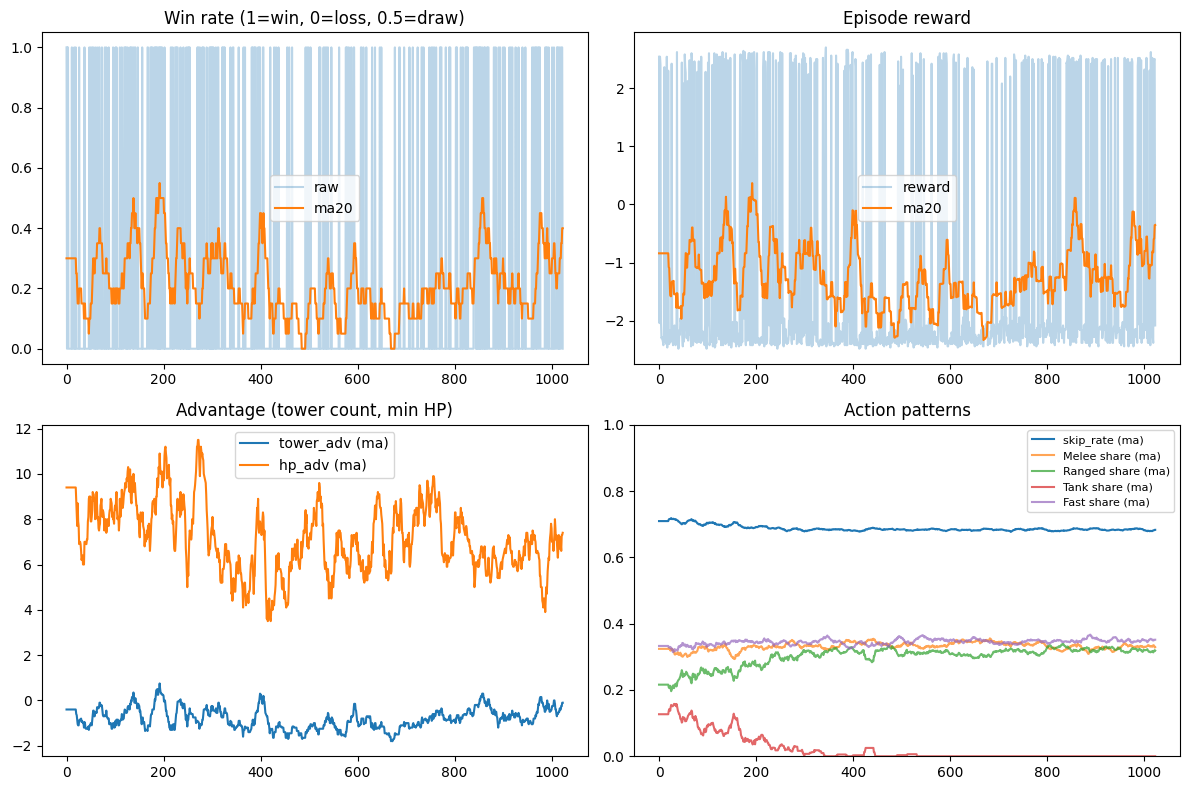

In [ ]:
plot_training('research/hrm-agent/runs', window=20)

In [ ]:
# Visualization for CRGymEnv HRM training logs
import os, json, glob
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Config
LOG_DIR = 'research/hrm-agent/runs'  # change if needed
ROLL = 20                            # rolling window for smoothing

plt.rcParams['figure.dpi'] = 560

# Load logs
files = sorted(glob.glob(os.path.join(LOG_DIR, 'episode_*.json')))
if not files:
  raise FileNotFoundError(f'No logs found in {LOG_DIR}')
records = []
for f in files:
  with open(f, 'r') as fh:
    rec = json.load(fh)
  m = rec.get('metrics', {})
  records.append({
    'episode': rec.get('episode', None),
    'reward_sum': m.get('reward_sum', None),
    'episode_len': m.get('episode_len', None),
    'winner': m.get('winner', None),
    'tower_advantage': m.get('tower_advantage', None),
    'hp_advantage': m.get('hp_advantage', None),
    'skip_rate': m.get('skip_rate', None),
    'lane_counts': m.get('lane_counts', {}),
    'place_counts': m.get('place_counts', {}),
    'card_type_counts': m.get('card_type_counts', {}),
  })

df = pd.DataFrame(records).sort_values('episode').reset_index(drop=True)
# Derived metrics
df['win'] = df['winner'].map({0: 1.0, 1: 0.0}).fillna(0.5)  # draw=0.5
df['reward_roll'] = df['reward_sum'].rolling(ROLL, min_periods=1).mean()
df['win_roll'] = df['win'].rolling(ROLL, min_periods=1).mean()
df['skip_roll'] = df['skip_rate'].rolling(ROLL, min_periods=1).mean()
df['tower_adv_roll'] = df['tower_advantage'].rolling(ROLL, min_periods=1).mean()
df['hp_adv_roll'] = df['hp_advantage'].rolling(ROLL, min_periods=1).mean()

# Aggregate categorical counters across episodes
def aggregate_counter(col):
  agg = Counter()
  for d in df[col]:
    if isinstance(d, dict):
      # keys may be strings in JSON
      cleaned = {k: int(v) for k, v in d.items()}
      agg.update(cleaned)
  return agg

lane_agg = aggregate_counter('lane_counts')
place_agg = aggregate_counter('place_counts')
card_agg = aggregate_counter('card_type_counts')

def to_pct_series(counter):
  total = sum(counter.values()) if counter else 0
  if total == 0:
    return pd.Series(dtype=float)
  s = pd.Series(counter, dtype=float)
  return (s / total).sort_index()

lane_pct = to_pct_series(lane_agg)
place_pct = to_pct_series(place_agg)
card_pct = to_pct_series(card_agg).sort_values(ascending=False)

# Plot
sns.set(style='whitegrid')
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, height_ratios=[1.0, 1.0, 1.0], hspace=0.35, wspace=0.25)

# Row 1: Reward and Winrate
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['episode'], df['reward_sum'], alpha=0.35, label='reward')
ax1.plot(df['episode'], df['reward_roll'], color='C1', label=f'reward (roll {ROLL})')
ax1.set_title('Reward per Episode')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Reward'); ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['episode'], df['win'], alpha=0.35, label='win (1=win,0=loss,0.5=draw)')
ax2.plot(df['episode'], df['win_roll'], color='C3', label=f'winrate (roll {ROLL})')
ax2.set_title('Winrate'); ax2.set_ylim(-0.05, 1.05)
ax2.set_xlabel('Episode'); ax2.set_ylabel('Winrate'); ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(df['episode'], df['episode_len'], color='C2', alpha=0.8)
ax3.set_title('Episode Length'); ax3.set_xlabel('Episode'); ax3.set_ylabel('Steps')

# Row 2: Skip, Tower, HP
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(df['episode'], df['skip_rate'], alpha=0.35, label='skip_rate')
ax4.plot(df['episode'], df['skip_roll'], color='C4', label=f'skip (roll {ROLL})')
ax4.set_title('Skip Rate'); ax4.set_ylim(0, 1)
ax4.set_xlabel('Episode'); ax4.set_ylabel('Rate'); ax4.legend()

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(df['episode'], df['tower_advantage'], alpha=0.35, label='tower_adv')
ax5.plot(df['episode'], df['tower_adv_roll'], color='C5', label=f'tower_adv (roll {ROLL})')
ax5.set_title('Tower Advantage'); ax5.set_xlabel('Episode'); ax5.set_ylabel('Advantage'); ax5.legend()

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(df['episode'], df['hp_advantage'], alpha=0.35, label='hp_adv')
ax6.plot(df['episode'], df['hp_adv_roll'], color='C6', label=f'hp_adv (roll {ROLL})')
ax6.set_title('HP Advantage'); ax6.set_xlabel('Episode'); ax6.set_ylabel('Advantage'); ax6.legend()

# Row 3: Aggregated Distributions
ax7 = fig.add_subplot(gs[2, 0])
if not lane_pct.empty:
  lane_pct.index = [str(k) for k in lane_pct.index]
  sns.barplot(x=lane_pct.index, y=lane_pct.values, ax=ax7, color='C0')
  ax7.set_title('Lane Choice Distribution'); ax7.set_xlabel('Lane'); ax7.set_ylabel('Fraction')
  ax7.set_ylim(0, 1)
else:
  ax7.set_title('Lane Choice Distribution (no data)')

ax8 = fig.add_subplot(gs[2, 1])
if not place_pct.empty:
  place_pct.index = [str(k) for k in place_pct.index]
  sns.barplot(x=place_pct.index, y=place_pct.values, ax=ax8, color='C1')
  ax8.set_title('Place Choice Distribution'); ax8.set_xlabel('Place'); ax8.set_ylabel('Fraction')
  ax8.set_ylim(0, 1)
else:
  ax8.set_title('Place Choice Distribution (no data)')

ax9 = fig.add_subplot(gs[2, 2])
if not card_pct.empty:
  sns.barplot(x=card_pct.index, y=card_pct.values, ax=ax9, color='C2')
  ax9.set_title('Card Type Usage'); ax9.set_xlabel('Card Type'); ax9.set_ylabel('Fraction')
  ax9.set_ylim(0, 1)
  ax9.tick_params(axis='x', rotation=20)
else:
  ax9.set_title('Card Type Usage (no data)')

plt.suptitle(f'CR HRM Training — {len(df)} episodes (rolling={ROLL})', y=1.02, fontsize=14)
plt.show()

# Optional: quick correlation check
corr_cols = ['reward_sum', 'win', 'skip_rate', 'tower_advantage', 'hp_advantage', 'episode_len']
print('Pairwise correlations (selected):')
print(df[corr_cols].corr().round(2))

Pairwise correlations (selected):
                 reward_sum   win  skip_rate  tower_advantage  hp_advantage  \
reward_sum             1.00  1.00       0.10             0.96          0.06   
win                    1.00  1.00       0.10             0.95          0.04   
skip_rate              0.10  0.10       1.00             0.09         -0.15   
tower_advantage        0.96  0.95       0.09             1.00          0.06   
hp_advantage           0.06  0.04      -0.15             0.06          1.00   
episode_len            0.14  0.13       0.72             0.16         -0.13   

                 episode_len  
reward_sum              0.14  
win                     0.13  
skip_rate               0.72  
tower_advantage         0.16  
hp_advantage           -0.13  
episode_len             1.00  


In [ ]:
rand_eval = evaluate_match(env, agent, RandomOpponent(), episodes=100, horizon=256, device=device)
rand_eval

{'winrate': 0.47, 'avg_tower_adv': -0.23, 'avg_hp_adv': -3.46}

In [ ]:
from uuid import uuid4

AGENT_PATH = 'research/hrm-agent/checkpoints'
torch.save(agent, AGENT_PATH + f'/{uuid4()}.pth')

In [ ]:
engine = CREngine()
engine.human_vs_agent(agent, human_team=1)

..l.k.r..
.........
.........
~~~~~~~~~
.........
.........
..L.K.R..
My Towers [K,L,R]: [20, 20, 20]
Opp Towers [K,L,R]: [20, 20, 20]
Hand: ['Fast(2)', 'Tank(5)']
Resource: 0/10
Lane actions: 0=left, 1=right | Place: 0=near, 1=far
Choose card: 0=front, 1=pre-front, 2=skip | lane: 0=left,1=right | place: 0=near,1=far


AttributeError: 'HRMAgentEntitiesMulti' object has no attribute 'select_card_action'